In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def plot_waterfall(
    df: pd.DataFrame,
    label_col: str = "tab_name",
    value_col: str = "measure_value",
    title: str = "Waterfall Analysis",
    ylabel: str = "Value (%)",
    bar_width: float = 0.65,
    figsize: tuple = (15, 7),
    bar_colors: list = None,
    y_limits: tuple = None,
    connector_color: str = "#7F8C8D",
    connector_lw: float = 1.5,
    bar_edgecolor=None,
    bar_linewidth: float = 1.2,
    min_bar_magnitude: float = 0.5,
    redistribute_adjustments: bool = False,
    snap_last_connector: bool = False,
    label_position: str = "dynamic"  # "dynamic", "up", "down"
):
    # ---------------- Validation ----------------
    if bar_colors is not None and len(bar_colors) != len(df):
        raise ValueError("Length of bar_colors must match number of rows in df")

    if isinstance(bar_edgecolor, list) and len(bar_edgecolor) != len(df):
        raise ValueError("Length of bar_edgecolor must match number of rows in df")

    if y_limits is not None and len(y_limits) != 2:
        raise ValueError("y_limits must be (ymin, ymax)")

    if label_position not in ("dynamic", "up", "down"):
        raise ValueError("label_position must be 'dynamic', 'up', or 'down'")

    # ---------------- True values ----------------
    true_values = df[value_col].values.astype(float)
    labels = df[label_col].values

    # ---------------- Apply min bar magnitude ----------------
    plot_values = true_values.copy()
    deltas = []

    for i in range(1, len(plot_values) - 1):
        if abs(plot_values[i]) < min_bar_magnitude and plot_values[i] != 0:
            adjusted = min_bar_magnitude if plot_values[i] > 0 else -min_bar_magnitude
            deltas.append(adjusted - plot_values[i])
            plot_values[i] = adjusted
        else:
            deltas.append(0.0)

    # ---------------- Redistribute excess if enabled ----------------
    if redistribute_adjustments:
        total_excess = sum(deltas)
        driver_count = len(plot_values) - 2

        if driver_count > 0 and total_excess != 0:
            redistribution = total_excess / driver_count
            for i in range(1, len(plot_values) - 1):
                plot_values[i] -= redistribution

    # ---------------- Cumulative values ----------------
    start_value = plot_values[0]
    end_value = plot_values[-1]

    cumulative = [start_value]
    for v in plot_values[1:-1]:
        cumulative.append(cumulative[-1] + v)

    x = np.arange(len(plot_values))

    # ---------------- Plot ----------------
    fig, ax = plt.subplots(figsize=figsize)

    # Bars
    for i, value in enumerate(plot_values):
        bottom = 0 if i in (0, len(plot_values) - 1) else cumulative[i - 1]
        ax.bar(
            x[i],
            value,
            bottom=bottom,
            width=bar_width,
            color=bar_colors[i] if bar_colors else (
                "#1F2A35" if i in (0, len(plot_values) - 1)
                else "#2E86C1" if value >= 0 else "#C0392B"
            ),
            edgecolor=(
                bar_edgecolor[i] if isinstance(bar_edgecolor, list)
                else bar_edgecolor
            ),
            linewidth=bar_linewidth if bar_edgecolor else 0
        )

    # ---------------- Connector lines ----------------
    for i in range(len(plot_values) - 1):

        x_start = x[i] + bar_width / 2
        x_end = x[i + 1] - bar_width / 2

        if i == 0:
            y_start = y_end = start_value
        else:
            y_start = y_end = cumulative[i]

        if i == len(plot_values) - 2 and snap_last_connector:
            y_start = cumulative[-1]
            y_end = end_value

        ax.plot(
            [x_start, x_end],
            [y_start, y_end],
            color=connector_color,
            linewidth=connector_lw
        )

    # ---------------- Axis styling ----------------
    if y_limits:
        ax.set_ylim(y_limits)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=16, pad=20)

    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ---------------- Value labels (outside bars, formatted) ----------------
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    offset = y_range * 0.015

    def format_pct(v):
        return f"{abs(v):.2f}%" if v >= 0 else f"({abs(v):.2f}%)"

    for i, val in enumerate(true_values):

        if i in (0, len(true_values) - 1):
            base_y = plot_values[i]
        else:
            base_y = cumulative[i - 1] + plot_values[i]

        if label_position == "up":
            y_text = base_y + offset
            va = "bottom"
        elif label_position == "down":
            y_text = base_y - offset
            va = "top"
        else:
            if plot_values[i] >= 0:
                y_text = base_y + offset
                va = "bottom"
            else:
                y_text = base_y - offset
                va = "top"

        ax.text(
            i,
            y_text,
            format_pct(val),
            ha="center",
            va=va,
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

In [38]:
df = pd.DataFrame({
    "tab_name": [
        "Pre",
        "Cat 1",
        "Cat 2",
        "Cat 3",
        "Cat 4",
        "Long Cat 5",
        "Cat 6",
        "Cat 7",
        "Cat 8",
        "Cat 9",
        "Very Very Long Cat 10",
        "Cat 11",
        "Cat 12",
        "Post"
    ],
    "measure_value": [
        100.0,
        38.043907,
        1.346411,
        0.0,
        0.0,
        0.0,
        -1.185802,
        -1.422878,
        -2.121001,
        -7.24334,
        -8.820831,
        -16.862987,
        0.000046,
        101.733526
    ]
})

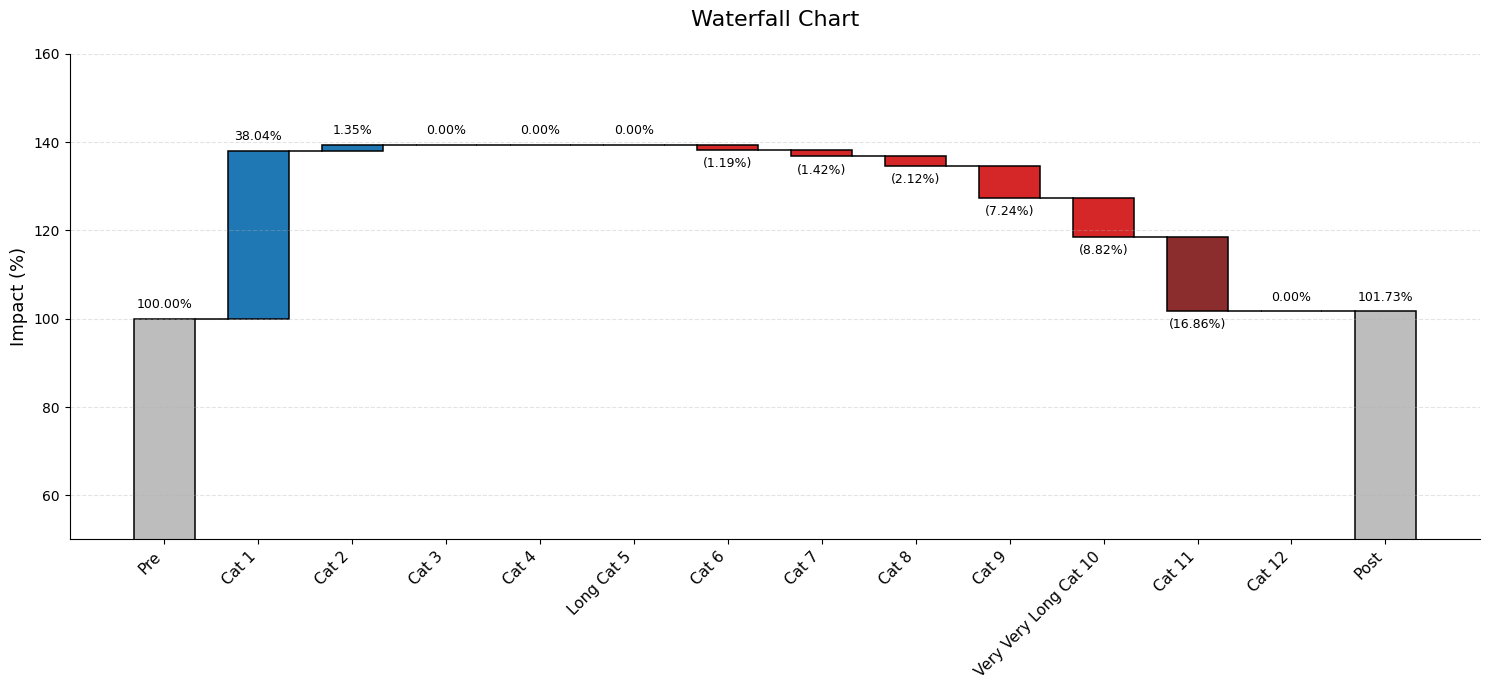

In [39]:
# --------------------------------------------------
# 3. Custom Colors (Per Bar)
# --------------------------------------------------
custom_colors = [
    "#BDBDBD",
    "#1F77B4",
    "#1F77B4",
    "#BDBDBD",
    "#BDBDBD",
    "#BDBDBD",
    "#D62728",
    "#D62728",
    "#D62728",
    "#D62728",
    "#D62728",
    "#8C2D2D",
    "#BDBDBD",
    "#BDBDBD"
]


# --------------------------------------------------
# 4. Plot
# --------------------------------------------------
#plot_waterfall(
#    df,
#    title="Waterfall Analysis: Calibration to Post",
#    bar_colors=custom_colors
#)


edge_colors = ["#000000"] * len(df)

plot_waterfall(
    df,
    title="Waterfall Chart",
    ylabel="Impact (%)",
    bar_colors=custom_colors,
    bar_edgecolor=edge_colors,
    bar_linewidth=1.1,
    connector_color="#000000",
    connector_lw=1.1,
    y_limits=(50, 160),
    min_bar_magnitude=0,
    redistribute_adjustments=True,
    snap_last_connector = True,
    label_position="dynamic"
)